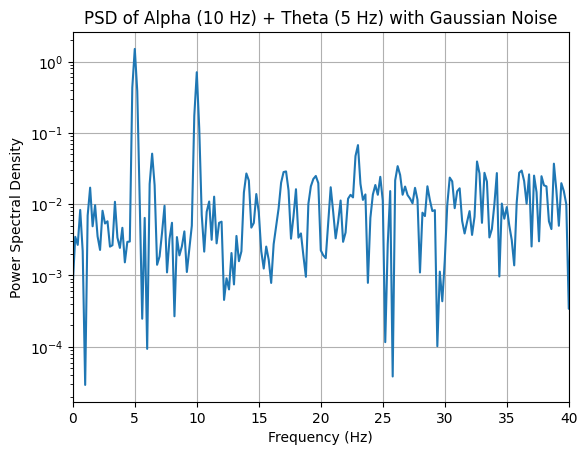

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Sampling parameters
fs = 200          # try 100, 200, 300
duration = 5     # seconds
t = np.linspace(0, duration, fs * duration, endpoint=False)

# Brain rhythms
theta = np.sin(2 * np.pi * 5 * t)       # 5 Hz
alpha = 0.6 * np.sin(2 * np.pi * 10 * t) # 10 Hz

# Combined signal
signal = theta + alpha

# Gaussian noise
noise_std = 1.0     # increase to see effect
noise = np.random.normal(0, noise_std, len(t))

signal_noisy = signal + noise

# Remove DC offset (IMPORTANT)
signal_noisy -= np.mean(signal_noisy)

# PSD using Welch method
freqs, psd = welch(
    signal_noisy,
    fs=fs,
    nperseg=fs*duration,     # 2-second windows
    noverlap=fs,      # 50% overlap
    window='hann'
)

# Plot PSD
plt.figure()
plt.semilogy(freqs, psd)
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD of Alpha (10 Hz) + Theta (5 Hz) with Gaussian Noise")
plt.grid(True)
plt.show()


In [4]:
import numpy as np
from scipy.signal import welch, butter, filtfilt, hilbert

# -----------------------------
# Dummy EEG signal (TEST INPUT)
# -----------------------------
fs = 100  # sampling frequency (Hz)
t = np.arange(0, 10, 1/fs)

# Simulated EEG: theta + alpha + noise
signal = (
    0.6 * np.sin(2*np.pi*6*t) +    # theta
    0.3 * np.sin(2*np.pi*10*t) +   # alpha
    0.2 * np.random.randn(len(t)) # noise
)

# -----------------------------
# Alpha / Theta ratio
# -----------------------------
def alpha_theta_ratio(signal, fs):
    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=fs*2,
        noverlap=fs//2
    )

    theta_mask = (freqs >= 4) & (freqs <= 8)
    alpha_mask = (freqs >= 8) & (freqs <= 13)

    theta_power = np.trapz(psd[theta_mask], freqs[theta_mask])
    alpha_power = np.trapz(psd[alpha_mask], freqs[alpha_mask])

    return alpha_power / theta_power

# -----------------------------
# Spindle detection
# -----------------------------
def bandpass(data, low, high, fs, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data)

spindle_band = bandpass(signal, 12, 14, fs)
analytic = hilbert(spindle_band)
envelope = np.abs(analytic)

threshold = np.mean(envelope) + 2*np.std(envelope)
spindle_events = envelope > threshold

# -----------------------------
# Sleep stage decision
# -----------------------------
ratio = alpha_theta_ratio(signal, fs)

state = "Wake"
if ratio > 1.5 and np.any(spindle_events):
    state = "N2"
elif ratio > 1.0:
    state = "N1"

print("Alpha/Theta ratio:", ratio)
print("Detected sleep stage:", state)


Alpha/Theta ratio: 0.25963264381168355
Detected sleep stage: Wake


C:\Users\Hp\AppData\Local\Temp\ipykernel_18488\45774756.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  theta_power = np.trapz(psd[theta_mask], freqs[theta_mask])
C:\Users\Hp\AppData\Local\Temp\ipykernel_18488\45774756.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  alpha_power = np.trapz(psd[alpha_mask], freqs[alpha_mask])
